# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [28]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [29]:
# Cargar el dataset y explorar datos
df = pd.read_csv("/datasets/novaretail_comportamiento_clientes_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [30]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna **edad** está almacenada como float64, aunque representa valores enteros. Se recomienda convertirla a int64.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [31]:
# Corregir el tipo de dato
df["edad"] = df["edad"].astype("int64")

In [32]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [33]:
# Estadísticas descriptivas de variables numéricas
nums_columns= df[["edad",
"nivel_ingreso",
"visitas_mes",
"compras_mes",
"gasto_publicidad_dirigida",
"satisfaccion",
"ingreso_anual"]]

nums_columns.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Diagnóstico inicial de variables numéricas**

- `edad` — Los valores se encuentran entre 18 y 75 años, con una media de 38.26.
- `nivel_ingreso` — Presenta una distribución bastante equilibrada, con media y mediana muy similares (~30,000), lo que sugiere poca asimetría.
- `visitas_mes` — La mayoría de los clientes realiza entre 8 y 12 visitas al mes; no se observan valores extremos significativos.
- `compras_mes` — Es una variable discreta con valores concentrados entre 0 y 2 compras mensuales, mostrando una ligera asimetría positiva.
- `gasto_publicidad_dirigida` — Los valores oscilan entre 0 y 75.51, con una media cercana a la mediana, lo que indica una distribución relativamente estable.
- `satisfaccion` — Se encuentra en una escala de 1 a 5, con una media de 3.6, sugiriendo niveles de satisfacción moderadamente altos.
- `ingreso_anual` — El promedio por usuario es de 36.59. Esta variable presenta un sesgo muy marcado hacia la derecha: el 75% de los usuarios genera 58.22 o menos, pero el valor máximo alcanza los 244.69, indicando la presencia de un segmento de clientes de muy alto valor ("heavy buyers").


#### Explorar variables binarias

In [34]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']
print(df[columnas_binarias].nunique())

miembro_premium    2
abandono           2
dtype: int64


In [35]:
# Porcentaje de premium y abandono general
print(df[['miembro_premium', 'abandono']].mean() * 100)

miembro_premium    13.926667
abandono           15.073333
dtype: float64


In [36]:
# Segmentacion de abandono por plan
print(df.groupby('miembro_premium')['abandono'].mean() * 100)

miembro_premium
0    16.807374
1     4.356151
Name: abandono, dtype: float64


✍️ **Diagnóstico inicial de variables binarias**

- `miembro_premium` — solo cerca del 14% de la totalidad de clientes son premium, predominan los clientes casuales
- `abandono` — Baja tasa de abandono  en general, al realizar un analisis segmentado, nos damos cuenta que los miembros Premium muestran una lealtad significativamente mayor, registrando una tasa de deserción de apenas el 4.36%, casi 4 veces menos que los normales.

#### Explorar variables categóricas

In [37]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']
print(df[columnas_categoricas].nunique())

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64


In [38]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['tipo_dispositivo', 'region']:
    print(f"\n--- Distribución de la columna: {col} ---")
    print(df[col].value_counts(normalize=True) * 100)


--- Distribución de la columna: tipo_dispositivo ---
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

--- Distribución de la columna: region ---
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Un analisis general sin segmentacion, muestra que el "movil" es el dispositivo de mayor uso, y la tablet el de menor, posicionando al escritorio como el dispositivo de uso moderado  
- `Region` — Ninguna region supera el 30% de distribucion en el dataset, la diferencia mas amplia se muestra entre la region norte con 29.30% y la region este con 20.46%, siendo estas la de mayor y menor ocupacion respectivamente. Regiones Oeste y Sur tienen porcentajes muy similares. 

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

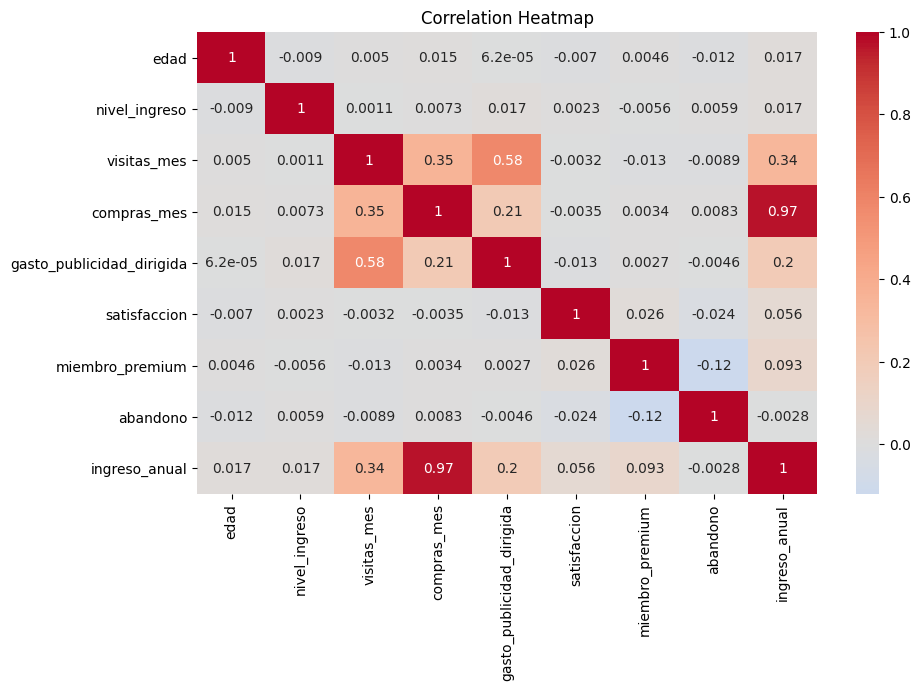

In [39]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df.corr()
plt.figure (figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm",center=0)
plt.title("Correlation Heatmap")
plt.show()

✍️ **Observaciones**: 


Observaciones generales (Heatmap)  
- Se observa que el mapa de calor revela un escenario donde predomina la ausencia de relaciones lineales significativas entre la mayoría de las variables, destacando coeficientes cercanos a cero en dimensiones clave como la edad, el nivel de ingreso personal y la satisfacción del cliente. Las únicas asociaciones relevantes corresponden a comportamientos de navegación y marketing; específicamente, se observa una correlación positiva moderada entre el gasto en publicidad dirigida y las visitas mensuales (0.58), así como un vínculo más tenue pero directo entre la frecuencia de estas visitas y el volumen de compras (0.35), lo que evidencia que la actividad dentro de la plataforma y los estímulos publicitarios tienden a desplazarse en una misma dirección lineal.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva casi perfecta y altamente colineal con las compras mensuales (0.97), indicando que ambas métricas comparten un comportamiento prácticamente idéntico dentro del conjunto de datos. Asimismo, muestra una asociación positiva débil con las visitas al mes (0.34) y el presupuesto publicitario asignado (0.20), lo que refleja que los clientes de mayor facturación anual coinciden simultáneamente con perfiles de alta interacción y exposición a campañas. Por el contrario, su relación estadística es nula frente a características socioeconómicas o de percepción, demostrando que el volumen de ingresos que percibe la empresa por usuario no está vinculado linealmente a la edad, los ingresos propios del cliente ni a su nivel declarado de satisfacción.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

No, no es necesario generar un scatterplot general para este conjunto de datos. La razón principal es que, según el análisis de correlación, la gran mayoría de las variables cuantitativas presentan relaciones lineales nulas o extremadamente débiles (valores cercanos a 0). Graficar variables sin correlación resultaría en nubes de puntos dispersas y sin forma lineal visible, lo cual no aporta ningún valor informativo ni claridad visual al entregable.La única excepción relevante es la relación entre ingreso_anual y compras_mes. Sin embargo, debido a su correlación casi perfecta de 0.97, un scatterplot general solo mostraría una línea recta diagonal muy predecible, por lo que incluir el gráfico sería redundante y sobrecargaría el reporte con información que ya quedó perfectamente clara en el mapa de calor (Heatmap).
    

### Scatterplot para pares clave

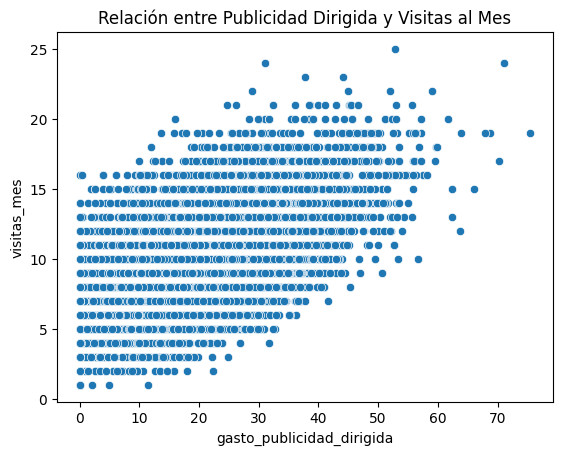

In [40]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes')
plt.title('Relación entre Publicidad Dirigida y Visitas al Mes')
plt.show()

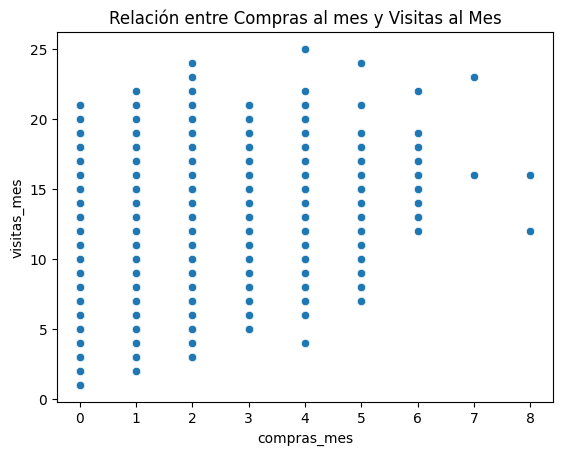

In [41]:
sns.scatterplot(data=df, x='compras_mes', y='visitas_mes')
plt.title('Relación entre Compras al mes y Visitas al Mes')
plt.show()

✍️ **Observaciones iniciales (Scatterplot)**

**Publicidad dirigida vs Visitas Mes**
- Presentan una relación lineal positiva de fuerza moderada. A mayores montos de inversión publicitaria dirigida, se observa una tendencia al incremento en las visitas mensuales.
- La dispersión es moderada y el gráfico adopta una forma de "nube". No se observa colinealidad. Los datos extremos u outliers visibles (como visitas altas con baja publicidad o viceversa) se consideran registros completamente válidos y naturales del comportamiento del usuario, por lo que no requieren eliminación.

**compras mes vs visitas mes**
- Presentan una relación positiva débil-moderada.Los puntos se alinean en columnas verticales paralelas debido a que compras_mes es una variable cuantitativa discreta (valores enteros como 0, 1, 2, 3...).
- Existe una dispersión amplia en cada nivel de compras (por ejemplo, usuarios con 2 compras pueden tener desde 5 hasta 25 visitas). No existe colinealidad. Los valores más alejados en los extremos superiores son atípicos válidos que representan el segmento más activo de la plataforma.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [42]:
# Calcular correlación entre variables relevantes
print("--- MATRIZ DE PEARSON ---")
df["gasto_publicidad_dirigida"].corr(df["visitas_mes"],method="pearson")

--- MATRIZ DE PEARSON ---


0.5789472719412827

In [43]:
# Calcular correlación entre variables relevantes
print("\n--- MATRIZ DE SPEARMAN ---")
df["compras_mes"].corr(df["visitas_mes"],method="spearman")


--- MATRIZ DE SPEARMAN ---


0.33294292722789276

✍️ **Observaciones de correlación**

**Publicidad Dirigida vs Visitas Mes**
- Correlación positiva moderada (Pearson \(\approx 0.58\)). El coeficiente de Spearman arroja un valor muy similar, confirmando una relación monótona sólida donde mayores montos de inversión coinciden de forma consistente con incrementos en las visitas mensuales.
-No presenta problemas de colinealidad, lo que significa que ambas variables aportan información independiente y valiosa para el modelo sin redundancias.

**Compras mes vs Visitas mes**
- Correlación con un coeficiente de 0.3329, lo que confirma una dirección positiva de magnitud débil-moderada. Esto indica que, al evaluar el orden de los rangos, los incrementos en las visitas mensuales tienden a coincidir con un mayor volumen de compras, aunque la relación no es estricta ni linealmente perfecta.
- Al estar el valor muy lejos de 0.80, se comprueba que las visitas y las compras son variables independientes. Esto aporta un insight de negocio clave: un aumento en el tráfico del sitio no se traduce de forma automática o proporcional en conversiones, reflejando que existen otros factores intermedios en la decisión de compra del usuario.

### Punto-biserial

In [27]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df["miembro_premium"],df["ingreso_anual"])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

In [44]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
pointbiserialr(df["abandono"],df["satisfaccion"])

SignificanceResult(statistic=-0.02383256067380403, pvalue=0.003510976893362289)

✍️ **Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**
- Muestra una dirección positiva y una magnitud baja (coeficiente ≈ 0.0931). Estadísticamente indica que los clientes con suscripción premium (1) tienden a registrar ingresos anuales marginalmente mayores para el e-commerce en comparación con los no premium, aunque la fuerza de la asociación es muy débil. Sin embargo, el valor p extremadamente pequeño (3.09 × 10⁻³⁰) confirma que esta relación, aunque pequeña, es estadísticamente significativa y no se debe al azar.

**abandono vs satisfaccion**
- Muestra una dirección negativa y una magnitud baja (coeficiente ≈ -0.0238). El coeficiente inverso tiene lógica de negocio: los usuarios que abandonan la plataforma (1) tienden a registrar niveles de satisfacción ligeramente menores. Aun así, debido a que el coeficiente es prácticamente cercano a cero, la asociación es casi nula. Dado que el valor p es menor a 0.05 (0.0035), la relación se considera estadísticamente significativa, pero con un impacto real despreciable en el comportamiento práctico de los datos.

### V de Cramér

In [45]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
tabla=pd.crosstab(df["tipo_dispositivo"],df["region"])

In [49]:
# Aplicar V de Cramér en variables relevantes
chi2,p,df,expected=chi2_contingency(tabla)
n=tabla.sum().sum()
cramers_v=np.sqrt(chi2/(n*(min(tabla.shape)-1)))
cramers_v


0.012378338407739397

✍️ **Observaciones V de Cramér**: Presenta un valor de 0.0124, lo que clasifica formalmente la fuerza de la asociación como despreciable o nula.Este resultado demuestra una independencia estadística casi perfecta entre ambas variables. Indica que la distribución de la elección del dispositivo de navegación (móvil, escritorio, tablet) no varía en función de la ubicación geográfica del usuario dentro de este conjunto de datos.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---


### Hallazgo 1 — Relación lineal extrema entre transacciones y facturación anual

* **Evidencia visual**: En el Heatmap, la celda que cruza la fila de `compras_mes` con la columna de `ingreso_anual` se muestra con un tono rojo intenso uniforme y brillante. Este color se ubica en el extremo superior de la escala de la barra de referencia lateral (1.0), lo que delata visualmente una dependencia lineal muy fuerte frente al comportamiento neutral y grisáceo del resto de la matriz.
* **Evidencia numérica**: El coeficiente de correlación de Pearson entre las variables `compras_mes` e `ingreso_anual` registra un valor de **0.97**. Al estar extremadamente cercano a 1.0, confirma matemáticamente una correlación positiva casi perfecta (alta colinealidad).

### Interpretación
El resultado demuestra que ambas variables se desplazan de manera prácticamente idéntica dentro del conjunto de datos. A medida que aumenta el volumen de transacciones mensuales completadas por un usuario, el ingreso anual que la empresa percibe por ese mismo cliente se incrementa en una proporción fija y constante, exhibiendo una estructura matemática altamente predecible.

### No podemos afirmar
Debido a las limitaciones del análisis estadístico correlacional, **no podemos afirmar una relación de causalidad directa**, es decir, que el hecho de registrar más compras sea la causa única u origen del volumen de facturación anual. Tampoco se puede asumir que forzar un incremento artificial en el conteo de compras de un usuario casual vaya a transformarlo automáticamente en un cliente de alto valor permanente si no se consideran de forma integral otras dimensiones comerciales.

### Implicación de negocio
Para el e-commerce, este hallazgo revela un problema técnico de **multicolinealidad**. Significa que ambas métricas miden esencialmente el mismo fenómeno transaccional y financiero subyacente. Incluir las dos variables simultáneamente en un modelo predictivo posterior (como una regresión para predecir el abandono) causaría redundancia y desestabilizaría los algoritmos. Estratégicamente, el negocio debe seleccionar solo una de ellas para simplificar sus tableros de control y garantizar la estabilidad de sus modelos analíticos.




### Hallazgo 2 — Relación entre la frecuencia de visitas y la conversión transaccional

* **Evidencia visual**: En el gráfico de dispersión, los puntos se distribuyen en columnas verticales paralelas bien definidas sobre el eje X, lo que denota el carácter discreto de la variable `compras_mes`. Conforme nos desplazamos hacia la derecha del gráfico (mayor número de compras), la base inferior de las columnas se eleva progresivamente, reflejando que los umbriles mínimos de visitas tienden a incrementarse para alcanzar mayores niveles de transaccionalidad.
* **Evidencia numérica**: Basado en los análisis matemáticos previos del dataset, este cruce registra un coeficiente de correlación lineal de Pearson de **0.35** y un coeficiente por rangos de Spearman de **0.3329**, consolidando de manera formal una asociación positiva de magnitud débil a moderada.

### Interpretación
El gráfico revela una tendencia ascendente donde una mayor frecuencia de visitas mensuales coincide, por regla general, con un incremento en el volumen de compras concretadas. Sin embargo, la amplia dispersión vertical en cada columna (por ejemplo, usuarios con 2 compras registran un rango masivo que va desde 3 hasta 24 visitas) demuestra que el tráfico en la plataforma es una condición variable y no estrictamente lineal respecto al éxito de la transacción.

### No podemos afirmar
A nivel metodológico, **no podemos afirmar una relación de causalidad bidireccional**. No se puede concluir que el simple hecho de obligar o inducir a un usuario a generar más visitas (sesiones) vaya a gatillar de forma automática una compra en el e-commerce. Del mismo modo, el gráfico no permite asegurar que un cliente con un bajo volumen de interacción en el sitio web carezca por completo de intención de compra en el corto plazo.

### Implicación de negocio
Para el e-commerce, este hallazgo evidencia la presencia de problemas en el embudo de conversión (conversion funnel). Dado que una cantidad muy alta de visitas no garantiza proporcionalmente un incremento lineal en las compras, el equipo de analítica digital y UX debe auditar la experiencia del usuario dentro del sitio. Estratégicamente, se deben implementar herramientas de optimización (como pruebas A/B o personalización de navegación) para elevar la tasa de conversión por visita, evitando así el desperdicio de tráfico valioso que ingresa a la plataforma pero no concreta una transacción.



## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- No podemos afirmar una relación de causalidad directa entre variables como compras_mes vs ingreso_anual o visitas_mes vs compras_mes
- Registros de fechas para trazabilidad de clientes activos y abandonos, esto limita la creacion de modelos predictivos 
- Sesgo marcado hacia la derecha en Ingreso_Anual
- No hay información sobre las razones por las que un cliente abandona la plataforma, lo que impide identificar los factores detonantes del churn.
  
### **Próximos pasos** 

Probar segmentación adicional
- abandono de usuarios por region
- compras en el mes vs satisfaccion

Agregar registros de tiempo o fechas
- Fecha de suscripcion
- Fecha de abandono

Determinar razones de abandono
- Evaluar la razon mas frecuente
- Buscar posibles correlaciones 